# 02 – Bias Detection & Fairness Analysis

This notebook evaluates potential discrimination in historical lending decisions.

The analysis includes:

- Disparate Impact Ratio (Gender)
- Age-based bias patterns
- Proxy discrimination detection
- Interaction effects between protected attributes

## Table of Contents

1. **Setup & Data Loading:** Connect to MongoDB, load clean baseline, engineer features
2. **Gender Bias Analysis:** Approval rates, Disparate Impact Ratio, chi-squared test
3. **Age Bias Analysis:** Age-group approval rates, DIR, financial profile comparison
4. **Proxy Discrimination (ZIP Code):** Geographic concentration, ZIP-gender correlation, conditional DIR
5. **Interaction Effects:** Gender x Age, Gender x Income quartile
6. **Algorithm Transparency Audit:** Rejection reason analysis, financial comparison
7. **Spending Category & Financial Fairness Check:** Small-sample proxy investigation, confirm financial parity
8. **Summary of Findings & Recommendations**

## 1. Setup & Regulatory Framework

This analysis is conducted against two key regulatory frameworks:

| Standard | Application |
|---|---|
| **Four-Fifths Rule (80% Rule)** | Disparate Impact Ratio < 0.80 indicates potential discrimination |
| **EU AI Act Art. 10** | High-risk AI systems must use training data that is relevant, representative, and free from bias |
| **EU AI Act Art. 13** | High-risk AI systems must be transparent and explainable to users |
| **EU AI Act Art. 14** | Human oversight must be ensured for high-risk AI decisions |
| **GDPR Art. 22** | Automated individual decision-making with legal effects requires safeguards |

Credit scoring is classified as a **high-risk AI system** under the EU AI Act (Annex III, point 5(b)).

In [48]:
import pandas as pd
import numpy as np
from scipy import stats
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Connect to MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['novacred']
collection = db['clean_credit_applications']

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print(f"Connected to: novacred.clean_credit_applications")
print(f"Document count: {collection.count_documents({})}")

Connected to: novacred.clean_credit_applications
Document count: 485


In [34]:
# Load all documents from the clean collection
docs = list(collection.find({}))
print(f"Documents loaded: {len(docs)}")

# Flatten nested structure into a DataFrame
records = []
for doc in docs:
    record = {
        '_id': doc['_id'],
        'gender': doc['applicant_info']['gender'],
        'zip_code': doc['applicant_info'].get('zip_code'),
        'age': doc.get('engineered_age'),
        'annual_income': doc['financials'].get('annual_income'),
        'credit_history_months': doc['financials'].get('credit_history_months'),
        'debt_to_income': doc['financials'].get('debt_to_income'),
        'savings_balance': doc['financials'].get('savings_balance'),
        'loan_approved': doc['decision']['loan_approved'],
        'rejection_reason': doc['decision'].get('rejection_reason'),
        'spending_behavior': doc.get('spending_behavior', [])
    }
    records.append(record)

df = pd.DataFrame(records)

# Engineer derived features
df['age_group'] = pd.cut(df['age'], bins=[0, 29, 49, 120], labels=['Under 30', '30-49', '50+'])
df['zip_prefix'] = df['zip_code'].astype(str).str[:3]
df['income_quartile'] = pd.qcut(df['annual_income'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

# Sanity check
print(f"DataFrame shape: {df.shape}")
print(f"\nGender distribution:\n{df['gender'].value_counts()}")
print(f"\nOverall approval rate: {df['loan_approved'].mean():.1%}")

Documents loaded: 485
DataFrame shape: (485, 14)

Gender distribution:
gender
Female    245
Male      240
Name: count, dtype: int64

Overall approval rate: 58.8%


---

## 2. Gender Bias Analysis

The **Four-Fifths Rule (80% Rule)** is the standard test for adverse impact in automated decision-making. The Disparate Impact Ratio (DIR) compares the approval rate of the disadvantaged group to that of the advantaged group:

$$DIR = \frac{\text{Approval Rate (Female)}}{\text{Approval Rate (Male)}}$$

A DIR below **0.80** constitutes prima facie evidence of disparate impact.

In [35]:
# Approval rates by gender
gender_stats = df.groupby('gender')['loan_approved'].agg(['sum', 'count', 'mean'])
gender_stats.columns = ['Approved', 'Total', 'Approval Rate']
gender_stats['Denied'] = gender_stats['Total'] - gender_stats['Approved']

print("=== Gender Approval Rates ===\n")
print(gender_stats[['Approved', 'Denied', 'Total', 'Approval Rate']].to_string())

# Disparate Impact Ratio
female_rate = gender_stats.loc['Female', 'Approval Rate']
male_rate = gender_stats.loc['Male', 'Approval Rate']
dir_gender = female_rate / male_rate

print(f"\nFemale approval rate: {female_rate:.1%}")
print(f"Male approval rate:   {male_rate:.1%}")
print(f"\nDisparate Impact Ratio (Female / Male): {dir_gender:.3f}")
print(f"Four-Fifths Threshold:                   0.800")
print(f"Status: {'PASS' if dir_gender >= 0.8 else 'FAIL - Below 0.80 threshold'}")

# Chi-squared test of independence
contingency = pd.crosstab(df['gender'], df['loan_approved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Statistically significant (p < 0.05): {'Yes' if p_value < 0.05 else 'No'}")

=== Gender Approval Rates ===

        Approved  Denied  Total  Approval Rate
gender                                        
Female       126     119    245       0.514286
Male         159      81    240       0.662500

Female approval rate: 51.4%
Male approval rate:   66.2%

Disparate Impact Ratio (Female / Male): 0.776
Four-Fifths Threshold:                   0.800
Status: FAIL — Below 0.80 threshold

Chi-squared statistic: 10.388
P-value: 0.0013
Statistically significant (p < 0.05): Yes


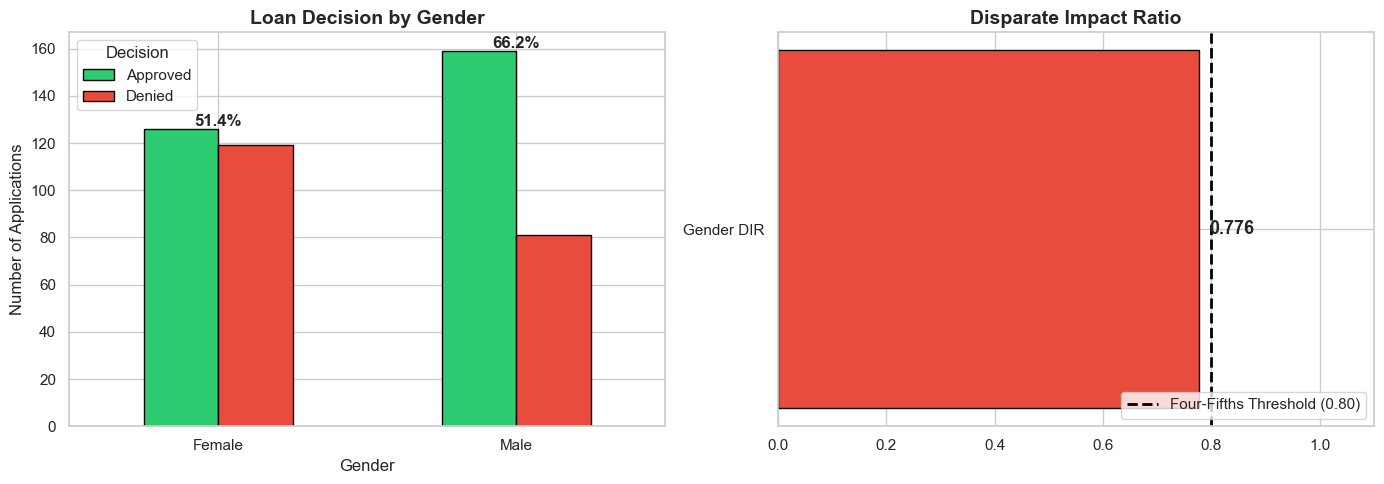

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Approval counts by gender
plot_data = gender_stats[['Approved', 'Denied']]
plot_data.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Loan Decision by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Applications')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Decision')
for i, gender in enumerate(['Female', 'Male']):
    rate = gender_stats.loc[gender, 'Approval Rate']
    axes[0].annotate(f'{rate:.1%}', xy=(i, gender_stats.loc[gender, 'Approved']),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: DIR gauge
categories = ['Gender DIR']
values = [dir_gender]
colors = ['#e74c3c' if v < 0.8 else '#2ecc71' for v in values]
axes[1].barh(categories, values, color=colors, edgecolor='black', height=0.4)
axes[1].axvline(x=0.8, color='black', linestyle='--', linewidth=2, label='Four-Fifths Threshold (0.80)')
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Disparate Impact Ratio', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
for i, v in enumerate(values):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Finding 1: Gender-Based Disparate Impact

| Metric | Value |
|---|---|
| Female approval rate | 51.4% |
| Male approval rate | 66.2% |
| **Disparate Impact Ratio** | **0.776** |
| Four-Fifths Threshold | 0.800 |
| Chi-squared p-value | 0.001 |

**Issue:** Female applicants are approved at a rate 14.8 percentage points lower than male applicants. The DIR of 0.776 falls below the 0.80 threshold established by the Four-Fifths Rule, indicating statistically significant adverse impact against women.

**Regulation:**
- **Four-Fifths Rule / 80% Rule:** DIR < 0.80 constitutes prima facie evidence of disparate impact.
- **EU AI Act Art. 10(2)(f):** Training data for high-risk AI must be examined for possible biases that are likely to lead to discrimination.

**Recommendation:** Immediately audit the credit scoring algorithm for features that correlate with gender. Implement pre-deployment bias testing as a mandatory step in the model lifecycle.

---

## 3. Age Bias Analysis

Age is protected under the EU Employment Equality Directive (2000/78/EC) and is relevant under the AI Act's fairness requirements. We apply the same DIR framework to evaluate age-based disparities across three cohorts: Under 30, 30-49, and 50+.

In [37]:
# Approval rates by age group
age_stats = df.groupby('age_group', observed=True)['loan_approved'].agg(['sum', 'count', 'mean'])
age_stats.columns = ['Approved', 'Total', 'Approval Rate']

print("=== Age Group Approval Rates ===\n")
print(age_stats.to_string())

# DIR: lowest rate / highest rate
min_rate = age_stats['Approval Rate'].min()
max_rate = age_stats['Approval Rate'].max()
dir_age = min_rate / max_rate
min_group = age_stats['Approval Rate'].idxmin()
max_group = age_stats['Approval Rate'].idxmax()

print(f"\nLowest rate:  {min_group} ({min_rate:.1%})")
print(f"Highest rate: {max_group} ({max_rate:.1%})")
print(f"\nAge DIR ({min_group} vs. {max_group}): {dir_age:.3f}")
print(f"Status: {'PASS' if dir_age >= 0.8 else 'FAIL - Below 0.80 threshold'}")

# Chi-squared test
contingency_age = pd.crosstab(df['age_group'], df['loan_approved'])
chi2_age, p_age, dof_age, _ = stats.chi2_contingency(contingency_age)
print(f"\nChi-squared statistic: {chi2_age:.3f}")
print(f"P-value: {p_age:.4f}")
print(f"Statistically significant: {'Yes' if p_age < 0.05 else 'No'}")

=== Age Group Approval Rates ===

           Approved  Total  Approval Rate
age_group                                
Under 30         34     78       0.435897
30-49           190    306       0.620915
50+              61    101       0.603960

Lowest rate:  Under 30 (43.6%)
Highest rate: 30-49 (62.1%)

Age DIR (Under 30 vs. 30-49): 0.702
Status: FAIL — Below 0.80 threshold

Chi-squared statistic: 8.921
P-value: 0.0116
Statistically significant: Yes


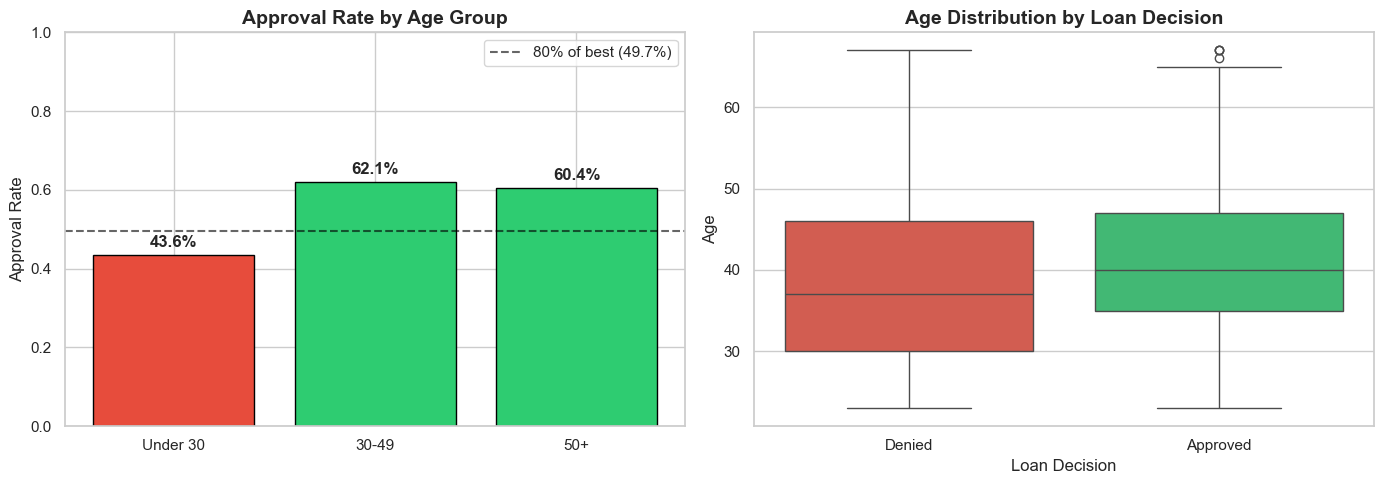

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Approval rates by age group
age_rates = age_stats['Approval Rate']
colors = ['#e74c3c' if r < 0.5 else '#f39c12' if r < 0.6 else '#2ecc71' for r in age_rates.values]
bars = axes[0].bar(age_rates.index, age_rates.values, color=colors, edgecolor='black')
axes[0].axhline(y=0.8 * max_rate, color='black', linestyle='--', alpha=0.6, label=f'80% of best ({0.8*max_rate:.1%})')
axes[0].set_title('Approval Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Approval Rate')
axes[0].set_ylim(0, 1)
axes[0].legend()
for bar, val in zip(bars, age_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.1%}',
                ha='center', fontsize=12, fontweight='bold')

# Plot 2: Age distribution by loan decision
sns.boxplot(data=df, x='loan_approved', y='age', ax=axes[1], 
            palette={True: '#2ecc71', False: '#e74c3c'}, hue='loan_approved', legend=False)
axes[1].set_title('Age Distribution by Loan Decision', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Denied', 'Approved'])
axes[1].set_xlabel('Loan Decision')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

In [39]:
# Do younger applicants actually have worse financial profiles?
# (Compare with Finding 7 where gender shows NO financial difference)
print("=== Financial Profile by Age Group ===\n")
print(f"{'Variable':<30} {'Under 30':>12} {'30-49':>12} {'50+':>12}")
print("-" * 70)

for var, label in [('annual_income', 'Annual Income'), ('credit_history_months', 'Credit History (months)'),
                   ('debt_to_income', 'Debt-to-Income'), ('savings_balance', 'Savings Balance')]:
    means = df.groupby('age_group', observed=True)[var].mean()
    print(f"{label:<30} {means['Under 30']:>12,.1f} {means['30-49']:>12,.1f} {means['50+']:>12,.1f}")

# T-test: Under 30 vs. 30-49 (the two groups in the DIR comparison)
print(f"\n=== T-Tests: Under 30 vs. 30-49 ===\n")
print(f"{'Variable':<30} {'t-statistic':>12} {'p-value':>10} {'Significant?':>15}")
print("-" * 70)

for var, label in [('annual_income', 'Annual Income'), ('credit_history_months', 'Credit History (months)'),
                   ('debt_to_income', 'Debt-to-Income'), ('savings_balance', 'Savings Balance')]:
    young = df[df['age_group'] == 'Under 30'][var].dropna()
    mid = df[df['age_group'] == '30-49'][var].dropna()
    t_stat, p_val = stats.ttest_ind(young, mid, equal_var=False)
    sig = 'Yes' if p_val < 0.05 else 'No'
    print(f"{label:<30} {t_stat:>12.3f} {p_val:>10.4f} {sig:>15}")

=== Financial Profile by Age Group ===

Variable                           Under 30        30-49          50+
----------------------------------------------------------------------
Annual Income                      50,239.4     90,105.3     86,262.6
Credit History (months)                28.6         45.5         83.8
Debt-to-Income                          0.2          0.2          0.2
Savings Balance                    17,412.5     31,654.9     32,090.3

=== T-Tests: Under 30 vs. 30-49 ===

Variable                        t-statistic    p-value    Significant?
----------------------------------------------------------------------
Annual Income                       -16.470     0.0000             Yes
Credit History (months)              -5.679     0.0000             Yes
Debt-to-Income                       -0.524     0.6012              No
Savings Balance                      -9.848     0.0000             Yes


### Finding 2: Age-Based Disparate Impact

| Age Group | Approved | Total | Approval Rate |
|---|---|---|---|
| Under 30 | 34 | 78 | 43.6% |
| 30-49 | 190 | 306 | 62.1% |
| 50+ | 61 | 101 | 60.4% |

| Metric | Value |
|---|---|
| **Age DIR** (Under 30 vs. 30-49) | **0.702** |
| Chi-squared p-value | 0.012 |

**Issue:** Applicants under 30 are approved at 43.6% compared to 62.1% for the 30-49 cohort, resulting in a DIR of 0.702, well below the 0.80 threshold.

**Important context:** Unlike the gender finding, where male and female applicants have statistically identical financial profiles (Finding 7), the age groups differ **substantially** on financial fundamentals. Under-30 applicants have lower income (€50,239 vs. €90,105), shorter credit histories (29 vs. 46 months), and lower savings (€17,413 vs. €31,655), all with p < 0.001. This means some of the approval rate gap is likely explained by **legitimate risk factors** rather than discrimination.

However, this does not fully exonerate the algorithm. The question is whether the 18.5 percentage point approval gap is *proportional* to the financial difference, or whether the model over-penalises youth beyond what the financials justify. The opacity of the `algorithm_risk_score` (Finding 5) makes it impossible to determine this without a full model audit.

**Regulation:**
- **EU AI Act Art. 10(2)(f):** The algorithm may be encoding age as a risk factor without properly disentangling it from correlated financial variables (credit history length, income), effectively double-counting youth as a risk signal.

**Recommendation:** Evaluate whether the model uses age directly or through proxies (e.g., credit history length). Consider age-adjusted scoring that normalises credit history expectations by age cohort. Unlike gender bias, age-based disparities require careful separation of legitimate risk factors from discriminatory penalisation.

---

## 4. Proxy Discrimination: ZIP Code Analysis

Proxy discrimination occurs when a facially neutral variable (e.g., ZIP code) is so strongly correlated with a protected attribute (e.g., gender) that it effectively acts as a substitute. Even if the algorithm does not use gender directly, relying on ZIP code may produce the same discriminatory outcome.

We investigate whether **ZIP code prefixes** in this dataset serve as a proxy for gender.

In [40]:
# Gender distribution by ZIP prefix
zip_gender = pd.crosstab(df['zip_prefix'], df['gender'])
zip_gender['Total'] = zip_gender.sum(axis=1)
zip_gender['Female %'] = zip_gender['Female'] / zip_gender['Total']
zip_gender['Male %'] = zip_gender['Male'] / zip_gender['Total']

print("=== Gender Concentration by ZIP Prefix ===\n")
for idx, row in zip_gender.sort_values('Female %').iterrows():
    dominant = 'Male' if row['Male %'] > 0.6 else ('Female' if row['Female %'] > 0.6 else 'Mixed')
    print(f"ZIP {idx}xx: {row['Female %']:.1%} Female, {row['Male %']:.1%} Male (n={int(row['Total'])}) - {dominant}")

# Approval rates by ZIP prefix
zip_approval = df.groupby('zip_prefix')['loan_approved'].agg(['mean', 'count'])
zip_approval.columns = ['Approval Rate', 'N']
print(f"\n=== Approval Rate by ZIP Prefix ===\n")
print(zip_approval.to_string())

# Chi-squared: ZIP prefix × gender
contingency_zg = pd.crosstab(df['zip_prefix'], df['gender'])
chi2_zg, p_zg, _, _ = stats.chi2_contingency(contingency_zg)
print(f"\nChi-squared (ZIP prefix x Gender): {chi2_zg:.1f}")
print(f"P-value: {p_zg:.2e}")
print(f"Statistically significant: {'Yes' if p_zg < 0.05 else 'No'}")

=== Gender Concentration by ZIP Prefix ===

ZIP 100xx: 11.5% Female, 88.5% Male (n=243) — Male
ZIP 300xx: 44.4% Female, 55.6% Male (n=18) — Mixed
ZIP 902xx: 93.3% Female, 6.7% Male (n=224) — Female

=== Approval Rate by ZIP Prefix ===

            Approval Rate    N
zip_prefix                    
100              0.646091  243
300              0.555556   18
902              0.526786  224

Chi-squared (ZIP prefix x Gender): 312.1
P-value: 1.67e-68
Statistically significant: Yes


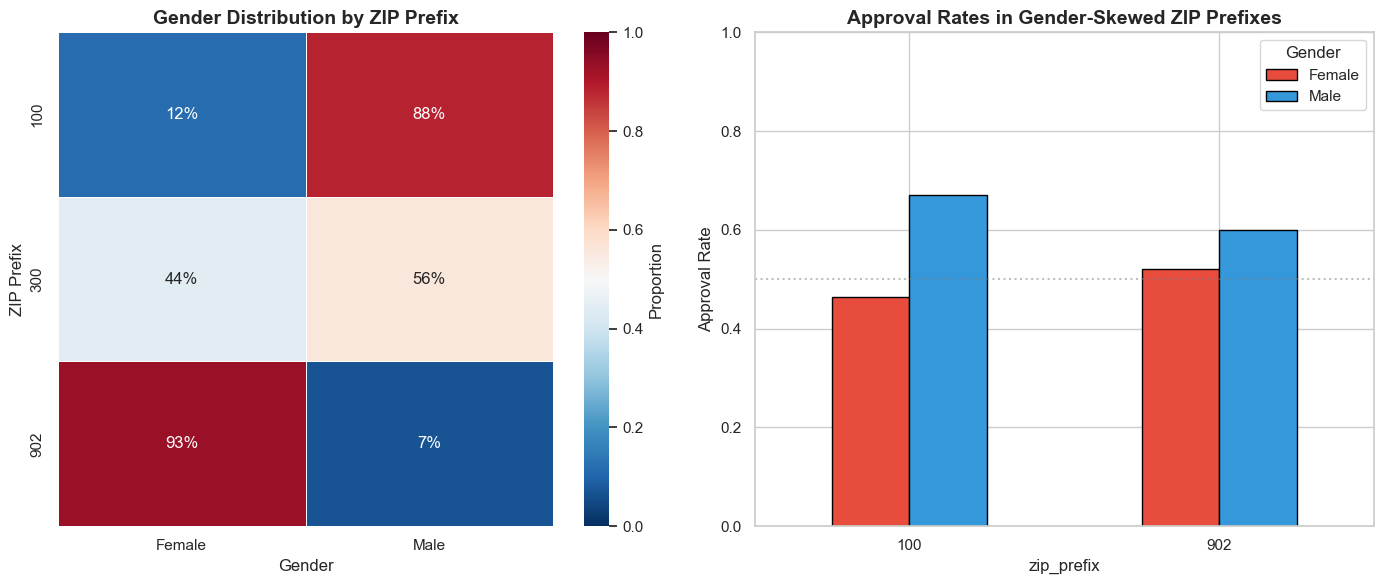

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Gender proportion by ZIP prefix (heatmap)
heatmap_data = pd.crosstab(df['zip_prefix'], df['gender'], normalize='index')
sns.heatmap(heatmap_data, annot=True, fmt='.0%', cmap='RdBu_r', center=0.5,
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Proportion'})
axes[0].set_title('Gender Distribution by ZIP Prefix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('ZIP Prefix')
axes[0].set_xlabel('Gender')

# Plot 2: Approval rates in the two most skewed ZIP prefixes, split by gender
key_zips = ['100', '902']
zip_subset = df[df['zip_prefix'].isin(key_zips)]
zip_rates = zip_subset.groupby(['zip_prefix', 'gender'])['loan_approved'].mean().unstack()
zip_rates.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'], edgecolor='black')
axes[1].set_title('Approval Rates in Gender-Skewed ZIP Prefixes', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Approval Rate')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

In [42]:
# Key test: does gender bias persist WITHIN the same ZIP prefix?
# If yes, ZIP is not merely a confounder - the gender penalty is independent of geography.

for prefix, label in [('100', 'NYC area'), ('902', 'LA area')]:
    subset = df[df['zip_prefix'] == prefix]
    print(f"=== Conditional Analysis: ZIP {prefix}xx ({label}, n={len(subset)}) ===\n")
    
    cond_stats = subset.groupby('gender')['loan_approved'].agg(['sum', 'count', 'mean'])
    cond_stats.columns = ['Approved', 'Total', 'Approval Rate']
    print(cond_stats.to_string())
    
    if 'Female' in cond_stats.index and 'Male' in cond_stats.index:
        f_rate = cond_stats.loc['Female', 'Approval Rate']
        m_rate = cond_stats.loc['Male', 'Approval Rate']
        cond_dir = f_rate / m_rate if m_rate > 0 else float('nan')
        print(f"\nConditional DIR (Female/Male): {cond_dir:.3f}")
        print(f"Status: {'PASS' if cond_dir >= 0.8 else 'FAIL - Below 0.80 threshold'}")
    else:
        print("\nInsufficient gender diversity for DIR calculation.")
    print()

=== Conditional Analysis: ZIP 100xx (NYC area, n=243) ===

        Approved  Total  Approval Rate
gender                                
Female        13     28       0.464286
Male         144    215       0.669767

Conditional DIR (Female/Male): 0.693
Status: FAIL — Below 0.80 threshold

=== Conditional Analysis: ZIP 902xx (LA area, n=224) ===

        Approved  Total  Approval Rate
gender                                
Female       109    209       0.521531
Male           9     15       0.600000

Conditional DIR (Female/Male): 0.869
Status: PASS



### Finding 3: ZIP Code as a Gender Proxy

**Correlation evidence:**
- ZIP prefix **100xx** (NYC area) is **88.5% male** - approval rate: 64.6%
- ZIP prefix **902xx** (LA area) is **93.3% female** - approval rate: 52.7%
- Chi-squared test (ZIP x Gender): **p < 0.001** - extreme statistical significance

**Conditional DIR test:**
- Within ZIP 100xx alone, gender DIR = **0.693** - still well below 0.80
- The gender penalty **persists even after controlling for geography**

**Issue:** ZIP code functions as a **proxy variable** for gender. The geographic concentration means that any model feature based on ZIP code will systematically disadvantage female applicants. This is a textbook case of proxy discrimination: a facially neutral variable that reproduces the effect of using a protected attribute directly.

**Regulation:**
- **EU AI Act Art. 10(2)(f):** The data governance framework must examine training data for "possible biases that are likely to lead to discrimination." ZIP code functioning as a gender proxy is precisely such a bias.
- **EU AI Act Art. 10(3):** Training datasets must be "relevant, representative, free of errors and complete." A dataset where geography proxies for gender fails the representativeness requirement.

**Recommendation:**
1. Remove or anonymise ZIP code data before model training, or replace with a geographic indicator that is not correlated with gender.
2. Conduct a feature importance audit to determine whether the model relies on ZIP code.
3. Implement proxy variable screening as part of the pre-deployment bias testing protocol.

---

## 5. Interaction Effects

Bias may not be uniform across all subgroups. We examine how gender bias varies across **age groups** and **income quartiles** to identify where discrimination is most concentrated.

In [43]:
# Gender DIR within each age group
print("=== Gender DIR by Age Group ===\n")

interaction_age = []
for group in ['Under 30', '30-49', '50+']:
    subset = df[df['age_group'] == group]
    f_rate = subset[subset['gender'] == 'Female']['loan_approved'].mean()
    m_rate = subset[subset['gender'] == 'Male']['loan_approved'].mean()
    dir_val = f_rate / m_rate if m_rate > 0 else np.nan
    n = len(subset)
    status = 'FAIL' if dir_val < 0.8 else 'PASS'
    interaction_age.append({'Age Group': group, 'Female Rate': f_rate, 'Male Rate': m_rate, 
                            'DIR': dir_val, 'N': n, 'Status': status})
    marker = '<-- FAIL' if dir_val < 0.8 else ''
    print(f"  {group}: Female={f_rate:.1%}, Male={m_rate:.1%}, DIR={dir_val:.3f} {marker}")

interaction_age_df = pd.DataFrame(interaction_age)

=== Gender DIR by Age Group ===

  Under 30: Female=36.6%, Male=51.4%, DIR=0.712 <-- FAIL
  30-49: Female=55.3%, Male=68.8%, DIR=0.803 
  50+: Female=51.9%, Male=69.4%, DIR=0.748 <-- FAIL


In [44]:
# Gender DIR within each income quartile
print("=== Gender DIR by Income Quartile ===\n")

interaction_income = []
for q in ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']:
    subset = df[df['income_quartile'] == q]
    f_rate = subset[subset['gender'] == 'Female']['loan_approved'].mean()
    m_rate = subset[subset['gender'] == 'Male']['loan_approved'].mean()
    dir_val = f_rate / m_rate if m_rate > 0 else np.nan
    n = len(subset)
    status = 'FAIL' if dir_val < 0.8 else 'PASS'
    interaction_income.append({'Income Quartile': q, 'Female Rate': f_rate, 'Male Rate': m_rate, 
                               'DIR': dir_val, 'N': n, 'Status': status})
    marker = '<-- FAIL' if dir_val < 0.8 else ''
    print(f"  {q}: Female={f_rate:.1%}, Male={m_rate:.1%}, DIR={dir_val:.3f} {marker}")

interaction_income_df = pd.DataFrame(interaction_income)

=== Gender DIR by Income Quartile ===

  Q1 (Low): Female=34.5%, Male=51.5%, DIR=0.670 <-- FAIL
  Q2: Female=43.1%, Male=71.9%, DIR=0.599 <-- FAIL
  Q3: Female=63.8%, Male=74.2%, DIR=0.860 
  Q4 (High): Female=62.7%, Male=69.2%, DIR=0.905 


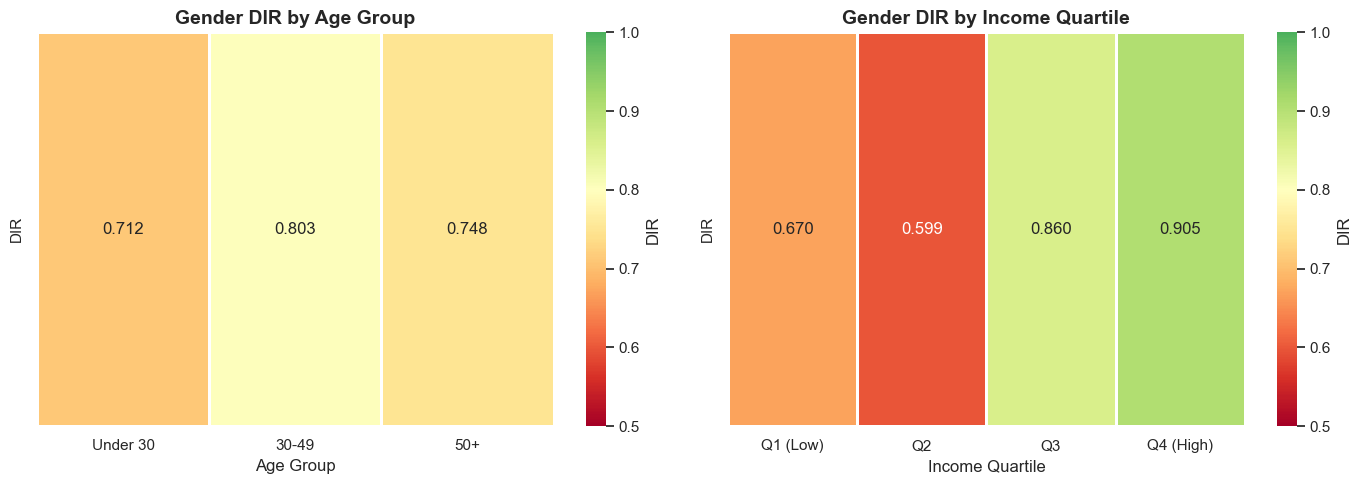

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gender DIR by Age Group heatmap
age_hm = interaction_age_df.set_index('Age Group')[['DIR']]
sns.heatmap(age_hm.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0.8,
            vmin=0.5, vmax=1.0, ax=axes[0], linewidths=1, cbar_kws={'label': 'DIR'})
axes[0].set_title('Gender DIR by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Plot 2: Gender DIR by Income Quartile heatmap
inc_hm = interaction_income_df.set_index('Income Quartile')[['DIR']]
sns.heatmap(inc_hm.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0.8,
            vmin=0.5, vmax=1.0, ax=axes[1], linewidths=1, cbar_kws={'label': 'DIR'})
axes[1].set_title('Gender DIR by Income Quartile', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Finding 4: Intersectional Bias Affecting Young and Low-Income Women

**Gender x Age:**
| Age Group | Female Rate | Male Rate | DIR | Status |
|---|---|---|---|---|
| Under 30 | 36.6% | 51.4% | 0.712 | FAIL |
| 30-49 | 55.3% | 68.8% | 0.803 | PASS (borderline) |
| 50+ | 51.9% | 69.4% | 0.748 | FAIL |

**Gender x Income:**
| Quartile | Female Rate | Male Rate | DIR | Status |
|---|---|---|---|---|
| Q1 (Low) | 34.5% | 51.5% | 0.670 | FAIL |
| Q2 | 43.1% | 71.9% | 0.599 | FAIL |
| Q3 | 63.8% | 74.2% | 0.860 | PASS |
| Q4 (High) | 62.7% | 69.2% | 0.905 | PASS |

**Issue:** Gender bias is most severe for **young women (under 30, DIR 0.712)** and **lower-income women (Q1-Q2, DIR 0.670 and 0.599)**. The algorithm disproportionately penalizes female applicants who are already economically vulnerable. The bias dissipates at higher income levels, suggesting the algorithm may amplify existing socioeconomic disadvantage rather than assessing credit risk objectively.

**Regulation:**
- **EU AI Act Art. 10(2)(f):** Intersectional bias patterns must be identified and mitigated. Examining gender in isolation masks the severity of harm to the most vulnerable subgroups.

**Recommendation:** Adopt intersectional fairness testing as standard practice. Evaluate DIR not only for single protected attributes but for their cross-tabulations. Prioritise remediation for the most disadvantaged subgroups.

---

## 6. Algorithm Transparency Audit

The EU AI Act Art. 13 requires that high-risk AI systems be designed to operate with sufficient **transparency** for users to interpret the system's output. We examine the **rejection reasons** provided by NovaCred's credit scoring system.

In [46]:
# Rejection reason breakdown
denied = df[df['loan_approved'] == False].copy()
print(f"=== Rejection Reason Analysis (n={len(denied)}) ===\n")
print(denied['rejection_reason'].value_counts().to_string())

algo_rejected = denied[denied['rejection_reason'] == 'algorithm_risk_score']
stated_rejected = denied[denied['rejection_reason'] != 'algorithm_risk_score']
print(f"\nAlgorithm-based rejections: {len(algo_rejected)}/{len(denied)} ({len(algo_rejected)/len(denied):.1%})")

# Compare financial profiles: algorithm-rejected vs. stated-reason rejected
print(f"\n=== Financial Profile Comparison ===")
print(f"{'Metric':<30} {'Algo-Rejected':>15} {'Stated-Reason':>15} {'Direction':>12} {'p-value':>10}")
print("-" * 85)

metrics = ['annual_income', 'debt_to_income', 'credit_history_months', 'savings_balance']
labels = ['Annual Income', 'Debt-to-Income', 'Credit History (months)', 'Savings Balance']

for metric, label in zip(metrics, labels):
    algo_mean = algo_rejected[metric].mean()
    stated_mean = stated_rejected[metric].mean()
    t_stat, p_val = stats.ttest_ind(algo_rejected[metric].dropna(), stated_rejected[metric].dropna(), equal_var=False)
    
    # For DTI, lower is better; for all others, higher is better
    if metric == 'debt_to_income':
        direction = "BETTER" if algo_mean < stated_mean else "WORSE"
    else:
        direction = "BETTER" if algo_mean > stated_mean else "WORSE"
    
    print(f"{label:<30} {algo_mean:>15,.1f} {stated_mean:>15,.1f} {direction:>12} {p_val:>10.4f}")

=== Rejection Reason Analysis (n=200) ===

rejection_reason
algorithm_risk_score           162
insufficient_credit_history     23
high_dti_ratio                  12
low_income                       3

Algorithm-based rejections: 162/200 (81.0%)

=== Financial Profile Comparison ===
Metric                           Algo-Rejected   Stated-Reason    Direction    p-value
-------------------------------------------------------------------------------------
Annual Income                         79,300.0        68,263.2       BETTER     0.0539
Debt-to-Income                             0.2             0.3       BETTER     0.0070
Credit History (months)                   49.1            28.8       BETTER     0.0001
Savings Balance                       28,255.0        21,128.6       BETTER     0.0109


### Finding 5: Opaque Algorithm with Paradoxical Outcomes

**Issue:** 81% of loan rejections cite only `algorithm_risk_score`, a generic label that provides no actionable feedback to applicants.

More concerning: applicants rejected by the algorithm have, on average, **better** financial profiles (higher income, longer credit history, lower DTI) than those rejected for explicitly stated financial reasons. This suggests the algorithm uses features beyond traditional financial metrics, possibly the proxy variables identified above.

**Regulation:**
- **EU AI Act Art. 13(1):** High-risk AI systems shall be designed so that their operation is sufficiently transparent to enable users to interpret the system's output.
- **EU AI Act Art. 14:** Human oversight measures shall ensure that human overseers can fully understand the AI system's capacities and limitations.
- **GDPR Art. 22(3):** Data subjects have the right to obtain meaningful information about the logic involved in automated decision-making.

**Recommendation:**
1. Replace `algorithm_risk_score` with specific, interpretable rejection reasons.
2. Implement a human-in-the-loop review for all algorithm-based rejections.
3. Provide applicants with a right to explanation and a mechanism to contest automated decisions.

---

## 7. Spending Category & Financial Fairness Check

We investigate whether lifestyle spending categories (Alcohol, Gambling, Adult Entertainment) serve as proxy variables, and whether core financial variables differ by gender.

In [47]:
# === Spending Category Proxy Check ===
print("=== Flagged Spending Categories ===\n")

# Build per-applicant flags for sensitive categories
flagged_cats = ['Alcohol', 'Gambling', 'Adult Entertainment']
applicant_flags = []
for _, row in df.iterrows():
    cats = [item['category'] for item in row['spending_behavior']] if isinstance(row['spending_behavior'], list) else []
    applicant_flags.append({
        '_id': row['_id'],
        'gender': row['gender'],
        'loan_approved': row['loan_approved'],
        'has_flagged': any(c in cats for c in flagged_cats)
    })

df_flags = pd.DataFrame(applicant_flags)
n_flagged = df_flags['has_flagged'].sum()

print(f"Applicants with flagged spending: {n_flagged} / {len(df_flags)}")
print(f"\nGender breakdown (flagged applicants):")
print(df_flags[df_flags['has_flagged']]['gender'].value_counts().to_string())

# Approval rate comparison
flagged_rate = df_flags[df_flags['has_flagged']]['loan_approved'].mean()
clean_rate = df_flags[~df_flags['has_flagged']]['loan_approved'].mean()
print(f"\nApproval rate - with flagged spending: {flagged_rate:.1%} (n={n_flagged})")
print(f"Approval rate - without:              {clean_rate:.1%} (n={len(df_flags) - n_flagged})")

# Chi-squared (likely not significant)
cont_flag = pd.crosstab(df_flags['has_flagged'], df_flags['gender'])
chi2_flag, p_flag, _, _ = stats.chi2_contingency(cont_flag)
print(f"\nChi-squared (flagged spending x gender): p = {p_flag:.3f}")
print(f"Statistically significant: {'Yes' if p_flag < 0.05 else 'No - sample too small for conclusions'}")

# === Financial Variable Fairness Check ===
print(f"\n\n=== Financial Variable Comparison by Gender ===\n")
print(f"{'Variable':<30} {'Female Mean':>15} {'Male Mean':>15} {'p-value':>10} {'Significant?':>15}")
print("-" * 88)

for var, label in [('annual_income', 'Annual Income'), ('credit_history_months', 'Credit History (months)'),
                   ('debt_to_income', 'Debt-to-Income'), ('savings_balance', 'Savings Balance')]:
    f_vals = df[df['gender'] == 'Female'][var].dropna()
    m_vals = df[df['gender'] == 'Male'][var].dropna()
    t_stat, p_val = stats.ttest_ind(f_vals, m_vals, equal_var=False)
    sig = 'Yes' if p_val < 0.05 else 'No'
    print(f"{label:<30} {f_vals.mean():>15,.1f} {m_vals.mean():>15,.1f} {p_val:>10.3f} {sig:>15}")

=== Flagged Spending Categories ===

Applicants with flagged spending: 22 / 485

Gender breakdown (flagged applicants):
gender
Male      12
Female    10

Approval rate — with flagged spending: 63.6% (n=22)
Approval rate — without:              58.5% (n=463)

Chi-squared (flagged spending x gender): p = 0.789
Statistically significant: No — sample too small for conclusions


=== Financial Variable Comparison by Gender ===

Variable                           Female Mean       Male Mean    p-value    Significant?
----------------------------------------------------------------------------------------
Annual Income                         84,649.1        81,171.5      0.171              No
Credit History (months)                   51.8            49.8      0.480              No
Debt-to-Income                             0.2             0.2      0.200              No
Savings Balance                       29,557.3        29,350.6      0.891              No


### Finding 6: Spending Categories (Insufficient Evidence)

The dataset includes spending categories such as Alcohol (n=11), Gambling (n=6), and Adult Entertainment (n=5). While these could theoretically serve as proxy variables, the sample size is too small (n=22 total) and the chi-squared test is not significant. **We cannot conclude that spending categories contribute to bias in this dataset.**

However, their inclusion in a credit scoring dataset is itself a governance concern: lifestyle spending categories have no established link to creditworthiness and risk encoding social prejudice into automated decisions.

### Finding 7: No Gender Difference in Financial Fundamentals

All four core financial variables show **no statistically significant gender differences** (all p > 0.15):
- Annual income, credit history length, debt-to-income ratio, and savings balance are comparable across genders.

**This is the most important supporting finding:** the observed gender bias in approval rates **cannot be explained by women having worse financial profiles.** The disparity must originate from the algorithm's use of non-financial features or from the opaque risk scoring mechanism itself.

---

## 8. Summary of Findings

| # | Finding | Key Metric | Threshold | Status | Regulation |
|---|---|---|---|---|---|
| 1 | Gender disparate impact | DIR = 0.776 | 0.80 | **FAIL** | Four-Fifths Rule, AI Act Art. 10 |
| 2 | Age bias (Under 30) | DIR = 0.702 | 0.80 | **FAIL**\* | AI Act Art. 10 |
| 3 | ZIP code as gender proxy | Chi-sq p < 0.001; conditional DIR = 0.693 | N/A | **FAIL** | AI Act Art. 10(2)(f), 10(3) |
| 4 | Intersectional bias | Young women DIR = 0.712; low-income women DIR = 0.599 | 0.80 | **FAIL** | AI Act Art. 10 |
| 5 | Opaque algorithm | 81% of rejections cite only "algorithm_risk_score" | N/A | **FAIL** | AI Act Art. 13, 14; GDPR Art. 22 |
| 6 | Spending categories as proxy | Chi-sq p = 0.789 (n=22) | 0.05 | Inconclusive | N/A |
| 7 | Financial parity across genders | All t-test p > 0.15 | 0.05 | **PASS** (no difference) | Supports findings 1-5 |

\* Age DIR fails the four-fifths threshold, but younger applicants have significantly weaker financial profiles (lower income, shorter credit history, lower savings, all p < 0.001). Some of the approval gap may reflect legitimate risk differences rather than discrimination. See Finding 2 for full context.

## Recommendations

1. **Immediate:** Suspend automated rejections based solely on `algorithm_risk_score` until the model can be audited for bias and made explainable (AI Act Art. 13, Art. 14).
2. **Short-term:** Remove or de-identify ZIP code from model features, or replace with a geographic indicator verified to not proxy for protected attributes.
3. **Short-term:** Implement the Four-Fifths Rule as a mandatory pre-deployment gate in the ML pipeline.
4. **Medium-term:** Adopt intersectional fairness testing (gender x age, gender x income) as standard model validation.
5. **Medium-term:** Provide applicants with meaningful rejection explanations and a right to human review (GDPR Art. 22, AI Act Art. 14).
6. **Ongoing:** Establish a bias monitoring dashboard that tracks DIR metrics on a rolling basis in production.